Kaggle Competition
Predicción del precio de una casa basada en el dataset de Boston Housing Price Competition(2006-2010)

Desglose del trabajo:

- Importar librerías necesarias
- Cargar el dataset
- EDA
- Visualización inicial
 Distribución de los precios de las casas
 Distribución de los datos
 Reconocer patrones vía gráfica
- Preprocesado
 Eliminar outliers
 Eliminar valores nulos o que NO utilicemos
 Codificar variables categóricas y/u ordinales
 Normalización
- Predicción: 
 Elegir modelo (punto de inicio)
 Entrenar modelo
 Evaluar modelo
- Análisis de la evaluación
 Evaluar rendimiento y confrontar test vs train
 Evaluar diferentes modelos predictivos (punto final)
 (Una vez decidido el modelo con mejor rendimiento)
 
 Generar curvas de aprendizaje con validación cruzada
- Visualización final
 Representación gráfica real vs pred
 Ver si hay overfitting o subfitting (visualizar)
 Mostrar las variables más importantes 
Visualización de tres casas más caras y más baratas
- Conclusiones
 Evaluar los criterios que afectan más y menos en la casas
 Características a evitar y a considerar para poder vender tu propia casa.

In [68]:
#Primer paso: importar librerías necesarias

#Pandas,Scipy,Pandas
import numpy as np
import scipy.stats as stats
import pandas as pd

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt

#Preprocesado
from statistics import mode
from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler,StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

#Predicción 
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor

# Evaluación
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, learning_curve,KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans

#Herramientas
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer,ColumnTransformer

import warnings
warnings.filterwarnings('ignore')




In [69]:
#Segundo paso: Cargar el dataset
df_train=pd.read_csv('./train.csv')
df_test=pd.read_csv('./test.csv')
df_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [70]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

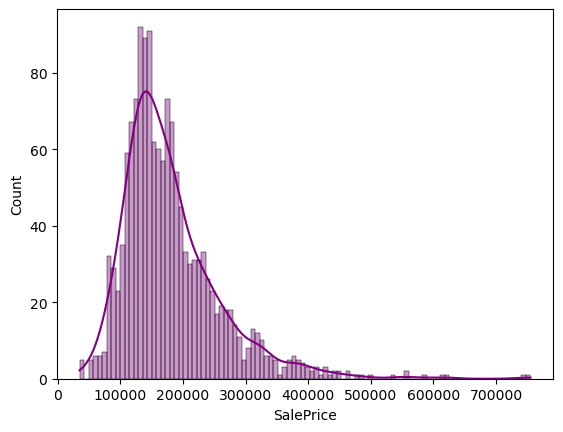

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [71]:
#A continuación mostraremos la distribucion de los precios de las casas y un resumen de las estadísticas más importantes 
sns.histplot(df_train['SalePrice'], color='Purple', bins=100, kde=True, alpha=0.4)
plt.show()
df_train['SalePrice'].describe()


- **Cantidad de registros (count)**: Se dispone de un total de 1460 observaciones sin valores nulos.

- **Media (mean)**: El precio promedio de las casas es de 180,921 dólares, lo que ofrece una primera referencia general del mercado.

- **Desviación estándar (std)**: Con un valor de aproximadamente 79,442 dólares, se evidencia una alta dispersión de los precios respecto a la media, indicando una importante variabilidad entre las propiedades.

- **Valor mínimo (min)**: La casa más económica registrada en el conjunto tiene un precio de 34,900 dólares.

- **Primer cuartil (25%)**: El 25% de las casas se vendieron por un precio igual o inferior a 129,975 dólares, reflejando el segmento de viviendas más accesibles.

- **Mediana (50%)**: El valor central de la distribución es de 163,000 dólares, lo que implica que la mitad de las casas tienen un precio inferior a este valor, y la otra mitad superior. 

- **Tercer cuartil (75%)**: El 75% de las viviendas tienen un precio de venta menor o igual a 214,000 dólares.

- **Valor máximo (max)**: El precio más alto registrado es de 755,000 dólares, lo cual confirma la presencia de propiedades de alto valor que pueden actuar como valores atípicos.

En general, se observa que la distribución del precio de las viviendas presenta un sesgo positivo (asimetría hacia la derecha), ya que la media es superior a la mediana. Esto sugiere la existencia de un número reducido de casas con precios considerablemente más altos que el resto, lo cual puede tener implicaciones importantes al momento de modelar esta variable, como la necesidad de aplicar una transformación logarítmica para normalizarla.

### EDA <a name="global"> </a>

Hay 1460 instancias de datos de entrenamiento y 1460 de datos de prueba. El número total de atributos es de 81, de los cuales 38 son cuantitativos y 43 categóricos, además de ID y precio de venta.

Cuantitativos:
 1stFlrSF, 2ndFlrSF, 3SsnPorch, BedroomAbvGr, BsmtFinSF1, BsmtFinSF2, BsmtFullBath, BsmtHalfBath, BsmtUnfSF, EnclosedPorch, Fireplaces, FullBath, GarageArea, GarageCars, GarageYrBlt, GrLivArea, HalfBath, KitchenAbvGr, LotArea, LotFrontage, LowQualFinSF, MSSubClass, MasVnrArea, MiscVal, MoSold, OpenPorchSF, OverallCond, OverallQual, PoolArea, ScreenPorch, TotRmsAbvGrd, TotalBsmtSF, WoodDeckSF, YearBuilt, YearRemodAdd, YrSold


Categóricos:
 Alley, BldgType, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, BsmtQual, CentralAir, Condition1, Condition2, Electrical, ExterCond, ExterQual, Exterior1st, Exterior2nd, Fence, FireplaceQu, Foundation, Functional, GarageCond, GarageFinish, GarageQual, GarageType, Heating, HeatingQC, HouseStyle, KitchenQual, LandContour, LandSlope, LotConfig, LotShape, MSZoning, MasVnrType, MiscFeature, Neighborhood, PavedDrive, PoolQC, RoofMatl, RoofStyle, SaleCondition, SaleType, Street, Utilities

In [72]:
var_num = df_train.select_dtypes(include=['int64', 'float64']).shape[1]
var_cat = df_train.select_dtypes(include=['object', 'category']).shape[1]

print(f"Variables numéricas: {var_num}")
print(f"Variables categóricas: {var_cat}")

Variables numéricas: 38
Variables categóricas: 43


El conjunto de datos contiene 20 variables continuas relacionadas con dimensiones de área, incluyendo tamaño del lote, superficie total de la vivienda y áreas específicas como sótanos, porches y salas principales, permitiendo diversas combinaciones y análisis.

Las 14 variables discretas cuantifican elementos en la casa, como número de cocinas, dormitorios, baños y capacidad del garaje, además de fechas de construcción o remodelación.

También hay 43 variables categóricas (26 nominales y 17 ordinales). Las nominales identifican tipos de viviendas, garajes y materiales, mientras que las ordinales califican características de la propiedad.

In [73]:
#Analizo un dataset hecho solo de las variables numéricas como primer enfoque.
df_num = df_train.select_dtypes(include = ['float64', 'int64'])
df_num.drop(columns=['Id'],inplace=True)
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


In [74]:
#Para mejorar el preprocesado, vamos a visualizar la relación que existe entre las variables numericas y el precio de la casa
#Esto nos sirve inicialmente para identificar Outliers y poder posteriormente eliminarlos.
#Influyen en el precio de forma negativa al ser casos raros.
df_num.dtypes

MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [75]:
#Función para facilitar la visión

def plot_relacion_num_precio(df, target="SalePrice"):
    # Obtener todas las columnas numéricas excepto el target
    numeric_columns = [col for col in df.columns if col != target]
    
    # Definir el número de filas y columnas para la disposición de los gráficos
    num_cols = 3  # Número de gráficos por fila
    num_rows = -(-len(numeric_columns) // num_cols)  # Redondeo hacia arriba

    # Crear figura con subgráficos
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
    axes = axes.flatten()  # Para iterar fácilmente en los subgráficos

    for i, col in enumerate(numeric_columns):
        df.plot(kind="scatter", x=col, y=target, ax=axes[i], alpha=0.5)
        axes[i].set_title(f"{col} vs {target}")

    # Eliminar gráficos vacíos si hay menos de num_rows * num_cols
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



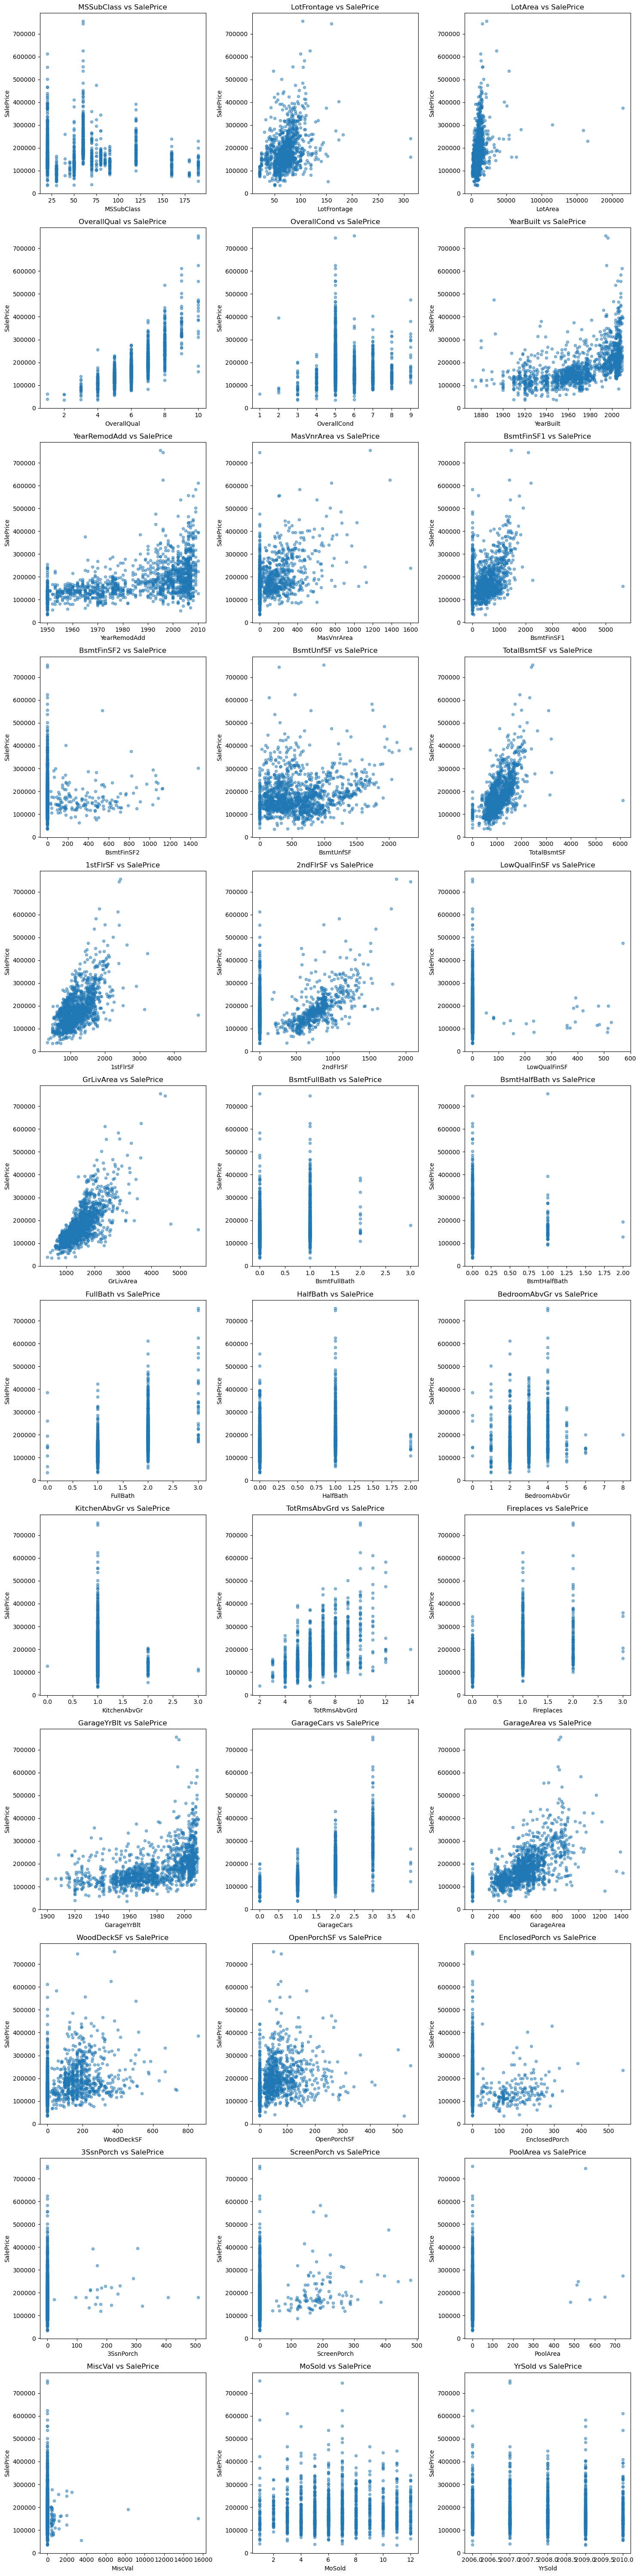

In [76]:

plot_relacion_num_precio(df_num, target="SalePrice")


| Variable | ¿Relación con SalePrice? | Interpretación rápida |
|:---|:---|:---|
| `MSSubClass` | Débil | Tipo de vivienda codificado como número (realmente es categórica disfrazada de numérica). |
| `LotFrontage` | Moderada positiva | Longitud de fachada → más fachada puede ayudar en el precio. |
| `LotArea` | Débil a moderada | Área del terreno; importante en terrenos muy grandes. |
| `OverallQual` | **Fuerte positiva** | Calidad general del material/acabado de la casa. |
| `OverallCond` | Débil negativa | Condición general de la casa; efecto menor que la calidad. |
| `YearBuilt` | Moderada positiva | Año de construcción; casas más nuevas tienden a valer más. |
| `YearRemodAdd` | Moderada positiva | Año de remodelación; remodelaciones recientes suben el precio. |
| `MasVnrArea` | Débil a moderada positiva | Área del revestimiento de ladrillo. |
| `BsmtFinSF1` | Moderada positiva | Área terminada del sótano (tipo 1). |
| `BsmtFinSF2` | Débil | Área terminada del sótano (tipo 2); menos relevante. |
| `BsmtUnfSF` | Débil | Área no terminada del sótano. |
| `TotalBsmtSF` | Moderada a fuerte positiva | Área total del sótano. |
| `1stFlrSF` | Moderada positiva | Superficie del primer piso. |
| `2ndFlrSF` | Moderada positiva | Superficie del segundo piso. |
| `LowQualFinSF` | Débil o nula | Superficie de baja calidad; generalmente negativa si es alta. |
| `GrLivArea` | **Fuerte positiva** | Área habitable sobre tierra; correlación muy fuerte. |
| `BsmtFullBath` | Débil a moderada positiva | Baños completos en el sótano. |
| `BsmtHalfBath` | Débil | Medios baños en el sótano. |
| `FullBath` | Moderada positiva | Baños completos en la casa. |
| `HalfBath` | Débil a moderada positiva | Medios baños en la casa. |
| `BedroomAbvGr` | Débil | Número de habitaciones sobre tierra. |
| `KitchenAbvGr` | Débil negativa | Demasiadas cocinas bajan el valor (normalmente 1 es ideal). |
| `TotRmsAbvGrd` | Débil a moderada positiva | Total de habitaciones sobre tierra. |
| `Fireplaces` | Moderada positiva | Número de chimeneas. |
| `GarageYrBlt` | Moderada positiva | Año de construcción del garaje. |
| `GarageCars` | **Fuerte positiva** | Capacidad del garaje en número de coches. |
| `GarageArea` | **Fuerte positiva** | Área del garaje en pies cuadrados. |
| `WoodDeckSF` | Débil positiva | Área de terraza de madera. |
| `OpenPorchSF` | Débil positiva | Porche abierto en pies cuadrados. |
| `EnclosedPorch` | Débil negativa | Porche cerrado; en exceso puede ser negativo. |
| `3SsnPorch` | Débil positiva | Porche de tres estaciones (cubierto). |
| `ScreenPorch` | Débil positiva | Porche con mosquitero. |
| `PoolArea` | Débil positiva | Área de piscina. |
| `MiscVal` | Nula o muy débil | Valor de otras construcciones, generalmente no influye. |
| `MoSold` | Nula | Mes en que se vendió; sin gran relación. |
| `YrSold` | Nula | Año de venta; podría ser relevante si hay inflación, pero en este dataset, no mucho. |


Identificamos el Id de los Outliers para poder eliminarlos


In [77]:
#Revisando caso por caso los valores atípicos, creo una lista con sus ID

atipicos = [598, 955, 935, 1299, 250, 314, 336, 707, 379, 1183, 692, 186, 441, 186, 524, 739, 598, 955, 636, 1062, 1191, 496, 198, 1338]

#Estos datos Id se colectan de cada columna, vemos que algunos valores se repiten en los caso atípicos

In [78]:
for i in atipicos:
    df_train.drop(index=df_train[df_train["Id"] == i].index, inplace=True)

df_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


A continuación veremos la nueva distribución del precio post Outliers.

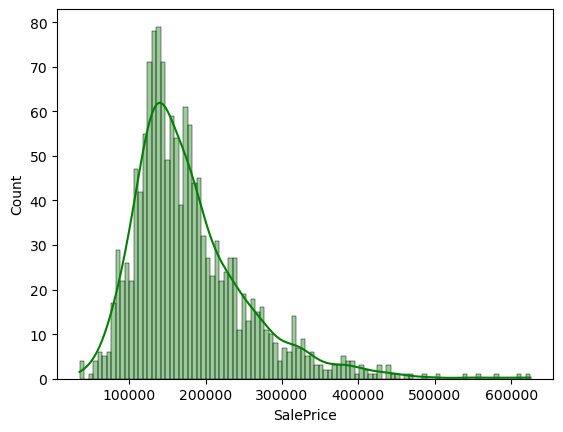

count      1439.000000
mean     179415.366921
std       75341.399716
min       35311.000000
25%      129900.000000
50%      162000.000000
75%      213125.000000
max      625000.000000
Name: SalePrice, dtype: float64

In [79]:
df_train.drop(columns=['Id'],inplace=True)

sns.histplot(df_train['SalePrice'], color='g', bins=100, kde=True, alpha=0.4)
plt.show()
df_train['SalePrice'].describe()

<function matplotlib.pyplot.show(close=None, block=None)>

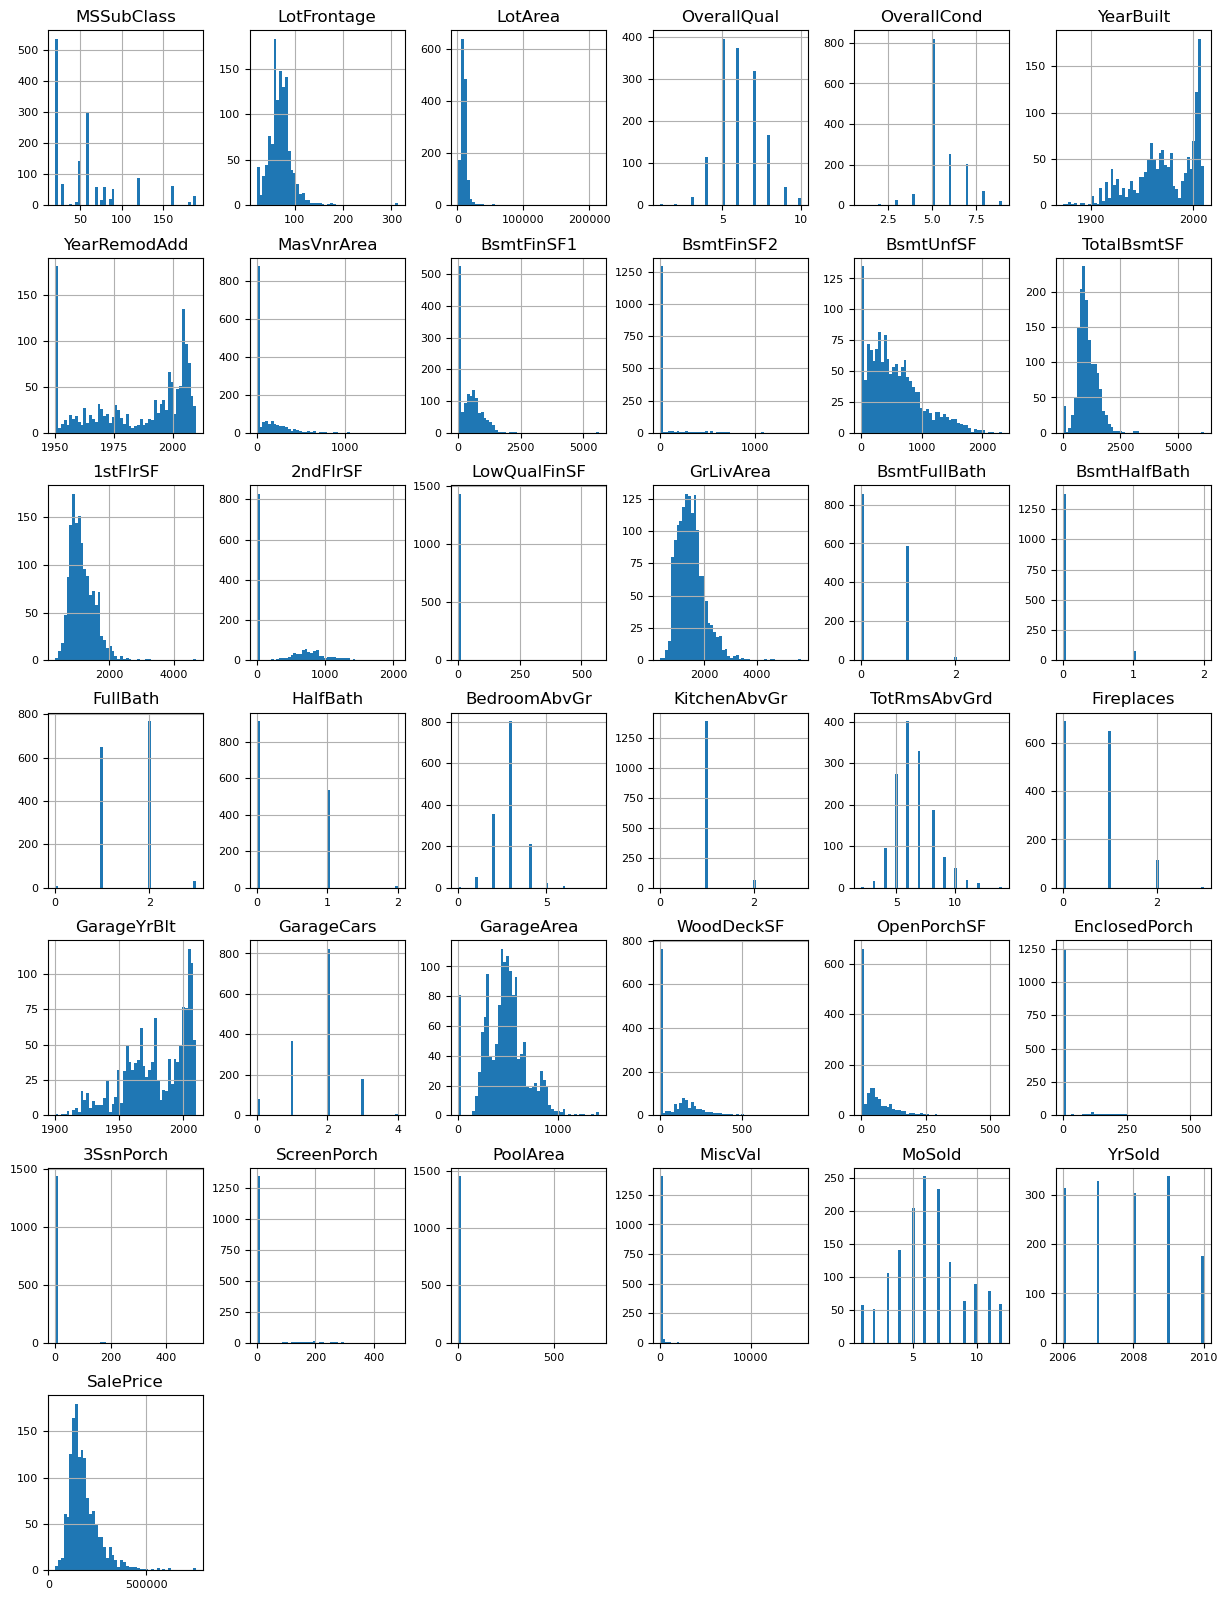

In [80]:
d_num=df_train.select_dtypes(include=['int64', 'float64']).shape[1]
df_num.hist(figsize=(15, 20), bins=50, xlabelsize=8, ylabelsize=8)
plt.show

Esta es la relación que hay entre cada columna y el precio de venta. A su vez utilizamos una función para ponerlas en orden de mayor a menor. La correlación que utilizamos no es la usual, pues parece que los datos no siguen una normal. En este caso, es más conveniente trabajar con la correlación de Spearman, ya que detecta relaciones entre variables incluso cuando no son lineales.


In [81]:
def ordenar_correlaciones(df_train, target_column='SalePrice'):
    correlaciones = {}  # Diccionario para almacenar las correlaciones

    for column in df_train.columns:
        if df_train[column].dtype in ['int64', 'float64']: 
            correlacion = df_train[target_column].corr(df_train[column],method='spearman')
            correlaciones[column] = correlacion

    correlaciones_ordenadas = {k: v for k, v in sorted(correlaciones.items(), key=lambda item: item[1], reverse=True)}

    for column, correlation in correlaciones_ordenadas.items():
        print(f"{column} = {correlation}")

- **Valor de correlación cercano a +1** → Relación positiva fuerte. (Cuando sube una, sube la otra.)

- **Valor cercano a -1** → Relación negativa fuerte. (Cuando sube una, baja la otra.)

- **Valor cercano a 0** → Casi sin relación.



In [82]:
print("Indice de correlación de variables numéricas:" )
ordenar_correlaciones(df_train)

Indice de correlación de variables numéricas:
SalePrice = 1.0
OverallQual = 0.8108030802713352
GrLivArea = 0.7269023188742251
GarageCars = 0.6939943755112002
YearBuilt = 0.6621177518747009
GarageArea = 0.6521213130358668
FullBath = 0.6371511615242754
GarageYrBlt = 0.6026838556056108
TotalBsmtSF = 0.598037692174584
YearRemodAdd = 0.5709350621627649
1stFlrSF = 0.566423348156405
TotRmsAbvGrd = 0.5268235389846138
Fireplaces = 0.5114081022732119
OpenPorchSF = 0.484991839211866
LotArea = 0.4500478311248939
MasVnrArea = 0.42416305375934915
LotFrontage = 0.4076055796865092
WoodDeckSF = 0.3556487181888476
HalfBath = 0.3454057511575973
BsmtFinSF1 = 0.2939104134859442
2ndFlrSF = 0.29199728787676393
BedroomAbvGr = 0.23192116136663662
BsmtFullBath = 0.21871842274055459
BsmtUnfSF = 0.18774870723335246
ScreenPorch = 0.09587735907745566
MoSold = 0.07686606887438613
3SsnPorch = 0.06750016710378759
PoolArea = 0.042028235761970976
MSSubClass = 0.0069621658546614295
BsmtHalfBath = -0.02226366954206888
YrS

### Manejo de datos ausentes <a name="global"> </a>


In [83]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1439 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1439 non-null   int64  
 1   MSZoning       1439 non-null   object 
 2   LotFrontage    1184 non-null   float64
 3   LotArea        1439 non-null   int64  
 4   Street         1439 non-null   object 
 5   Alley          89 non-null     object 
 6   LotShape       1439 non-null   object 
 7   LandContour    1439 non-null   object 
 8   Utilities      1439 non-null   object 
 9   LotConfig      1439 non-null   object 
 10  LandSlope      1439 non-null   object 
 11  Neighborhood   1439 non-null   object 
 12  Condition1     1439 non-null   object 
 13  Condition2     1439 non-null   object 
 14  BldgType       1439 non-null   object 
 15  HouseStyle     1439 non-null   object 
 16  OverallQual    1439 non-null   int64  
 17  OverallCond    1439 non-null   int64  
 18  YearBuilt    

In [84]:
ausentes= pd.DataFrame(df_train.isnull().sum().sort_values(ascending=False)).head(19) #solo fui tocando este valor hasta que queden las que tienen valores nulos
columnas_ausentes = df_train.columns[df_train.isnull().sum() > 0].tolist()

In [85]:
ausentes

,0
PoolQC,1435
MiscFeature,1388
Alley,1350
Fence,1162
MasVnrType,861
FireplaceQu,684
LotFrontage,255
GarageYrBlt,76
GarageCond,76
GarageType,76


In [86]:
def llenar_valores_ausentes(df):
    # Llenar valores en BsmtFinType2 y Electrical con valores específicos
    df['BsmtFinType2'].fillna("Unf", inplace=True)
    df['Electrical'].fillna("SBrkr", inplace=True)
    
    for col in df.columns:
        if df[col].isnull().sum() > 0:  
            if df[col].dtype == 'object':
                df[col].fillna("No", inplace=True)
            else:
                df[col].fillna(0, inplace=True)
    
    return df

In [87]:
llenar_valores_ausentes(df_test)
df_test.drop(columns='Id')
llenar_valores_ausentes(df_train)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,No,Reg,Lvl,AllPub,Inside,...,0,No,No,No,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,No,Reg,Lvl,AllPub,FR2,...,0,No,No,No,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,No,IR1,Lvl,AllPub,Inside,...,0,No,No,No,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,No,IR1,Lvl,AllPub,Corner,...,0,No,No,No,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,No,IR1,Lvl,AllPub,FR2,...,0,No,No,No,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,No,Reg,Lvl,AllPub,Inside,...,0,No,No,No,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,No,Reg,Lvl,AllPub,Inside,...,0,No,MnPrv,No,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,No,Reg,Lvl,AllPub,Inside,...,0,No,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,No,Reg,Lvl,AllPub,Inside,...,0,No,No,No,0,4,2010,WD,Normal,142125


In [88]:
def catplot_valores_ausentes(df_train, target="SalePrice"):

    num_cols = 3  # Número de gráficos por fila
    num_rows = -(-len(columnas_ausentes) // num_cols)  # Redondeo hacia arriba
    
    # Crear figura con subgráficos
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 3))
    axes = axes.flatten()  # Para iterar fácilmente en los subgráficos
    
    for i, col in enumerate(columnas_ausentes):
        sns.boxplot(data=df_train, x=col, y=target, ax=axes[i])
        axes[i].set_title(f"{col} vs {target}")
    
    # Eliminar gráficos vacíos si hay menos de num_rows * num_cols
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()



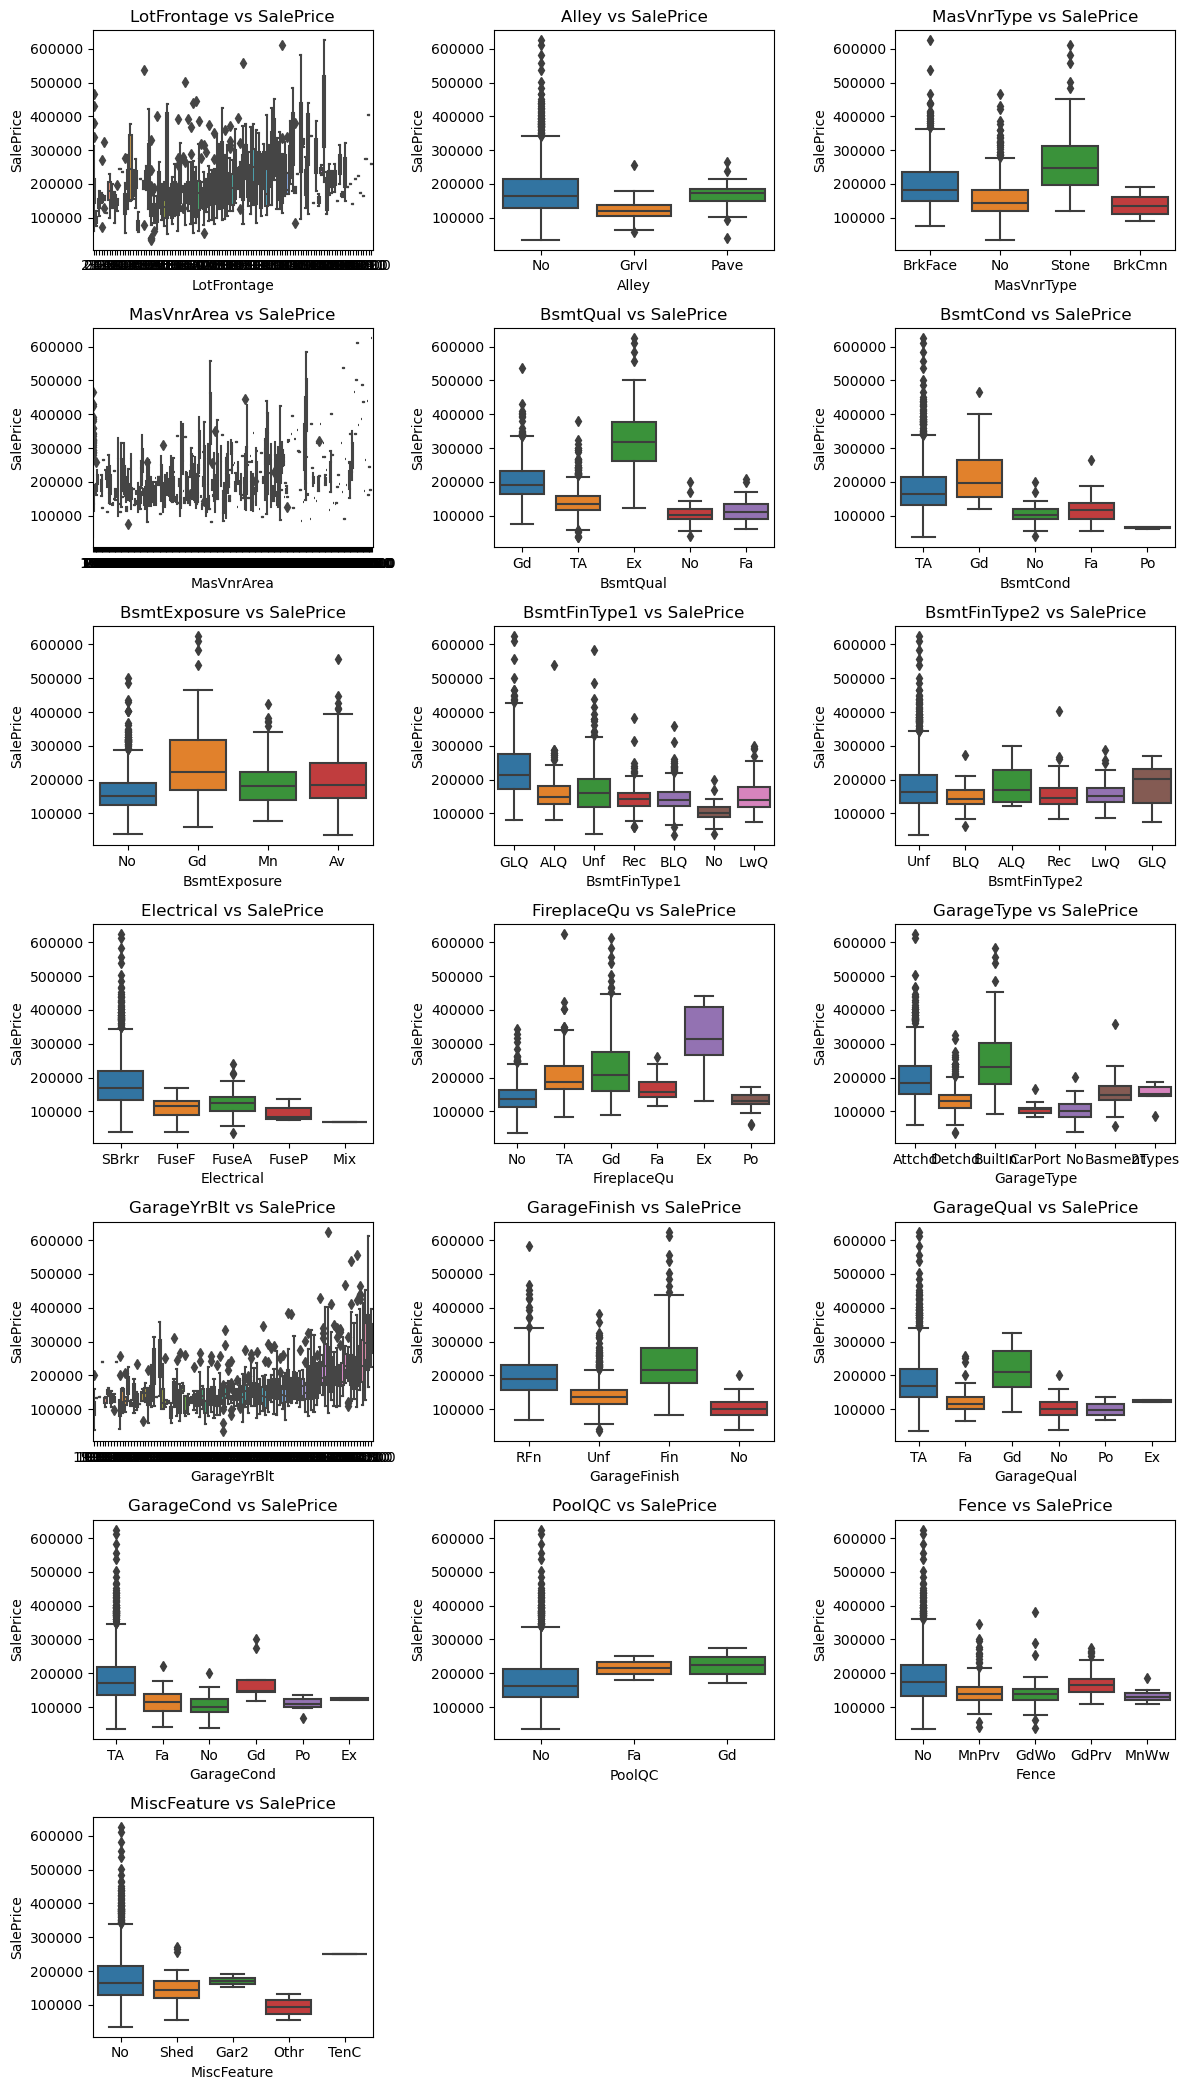

In [89]:
catplot_valores_ausentes(df_train,"SalePrice")

In [90]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1439 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1439 non-null   int64  
 1   MSZoning       1439 non-null   object 
 2   LotFrontage    1439 non-null   float64
 3   LotArea        1439 non-null   int64  
 4   Street         1439 non-null   object 
 5   Alley          1439 non-null   object 
 6   LotShape       1439 non-null   object 
 7   LandContour    1439 non-null   object 
 8   Utilities      1439 non-null   object 
 9   LotConfig      1439 non-null   object 
 10  LandSlope      1439 non-null   object 
 11  Neighborhood   1439 non-null   object 
 12  Condition1     1439 non-null   object 
 13  Condition2     1439 non-null   object 
 14  BldgType       1439 non-null   object 
 15  HouseStyle     1439 non-null   object 
 16  OverallQual    1439 non-null   int64  
 17  OverallCond    1439 non-null   int64  
 18  YearBuilt    

In [91]:
df_train['HouseAge'] = df_train['YrSold'] - df_train['YearBuilt']
df_test['HouseAge'] = df_test['YrSold'] - df_test['YearBuilt']

In [92]:
df_train['TotalArea'] = df_train['GrLivArea'] + df_train['TotalBsmtSF']
df_test['TotalArea'] = df_test['GrLivArea'] + df_test['TotalBsmtSF']


In [93]:
df_train['TotalSF'] = df_train['1stFlrSF'] + df_train['2ndFlrSF'] + df_train['BsmtFinSF1'] + df_train['BsmtFinSF2']
df_test['TotalSF'] = df_test['1stFlrSF'] + df_test['2ndFlrSF'] + df_test['BsmtFinSF1'] + df_test['BsmtFinSF2']

In [94]:
df_train['TotalArea'] = df_train['GrLivArea'] + df_train['TotalBsmtSF']
df_test['TotalArea'] = df_test['GrLivArea'] + df_test['TotalBsmtSF']

In [95]:
df_train['TotalBaths'] = df_train['BsmtFullBath'] + df_train['FullBath'] + 0.5 * (df_train['BsmtHalfBath'] + df_train['HalfBath'])  #para hacer la media
df_test['TotalBaths'] = df_test['BsmtFullBath'] + df_test['FullBath'] + 0.5 * (df_test['BsmtHalfBath'] + df_test['HalfBath']) 

In [96]:
df_train['TotalPorchSF'] = df_train['OpenPorchSF'] + df_train['3SsnPorch'] + df_train['EnclosedPorch'] + df_train['ScreenPorch'] + df_train['WoodDeckSF']
df_test['TotalPorchSF'] = df_test['OpenPorchSF'] + df_test['3SsnPorch'] + df_test['EnclosedPorch'] + df_test['ScreenPorch'] + df_test['WoodDeckSF']

In [97]:
df_train = df_train.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF'])
df_test = df_test.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF'])

In [98]:
ordenar_correlaciones(df_train)

SalePrice = 1.0
TotalArea = 0.8122718665873113
OverallQual = 0.8108030802713352
TotalBaths = 0.7025865201260233
TotalSF = 0.7024589192065027
GarageCars = 0.6939943755112002
GarageArea = 0.6521213130358668
GarageYrBlt = 0.6427765533126097
TotRmsAbvGrd = 0.5268235389846138
Fireplaces = 0.5114081022732119
LotArea = 0.4500478311248939
TotalPorchSF = 0.4280062297660187
MasVnrArea = 0.41862932637883576
LotFrontage = 0.23824358254586137
BedroomAbvGr = 0.23192116136663662
BsmtUnfSF = 0.18774870723335246
MoSold = 0.07686606887438613
PoolArea = 0.042028235761970976
MSSubClass = 0.0069621658546614295
MiscVal = -0.0667182444737629
LowQualFinSF = -0.09169668874491203
OverallCond = -0.13761691168261433
KitchenAbvGr = -0.17299568395371162
HouseAge = -0.6595830079937607


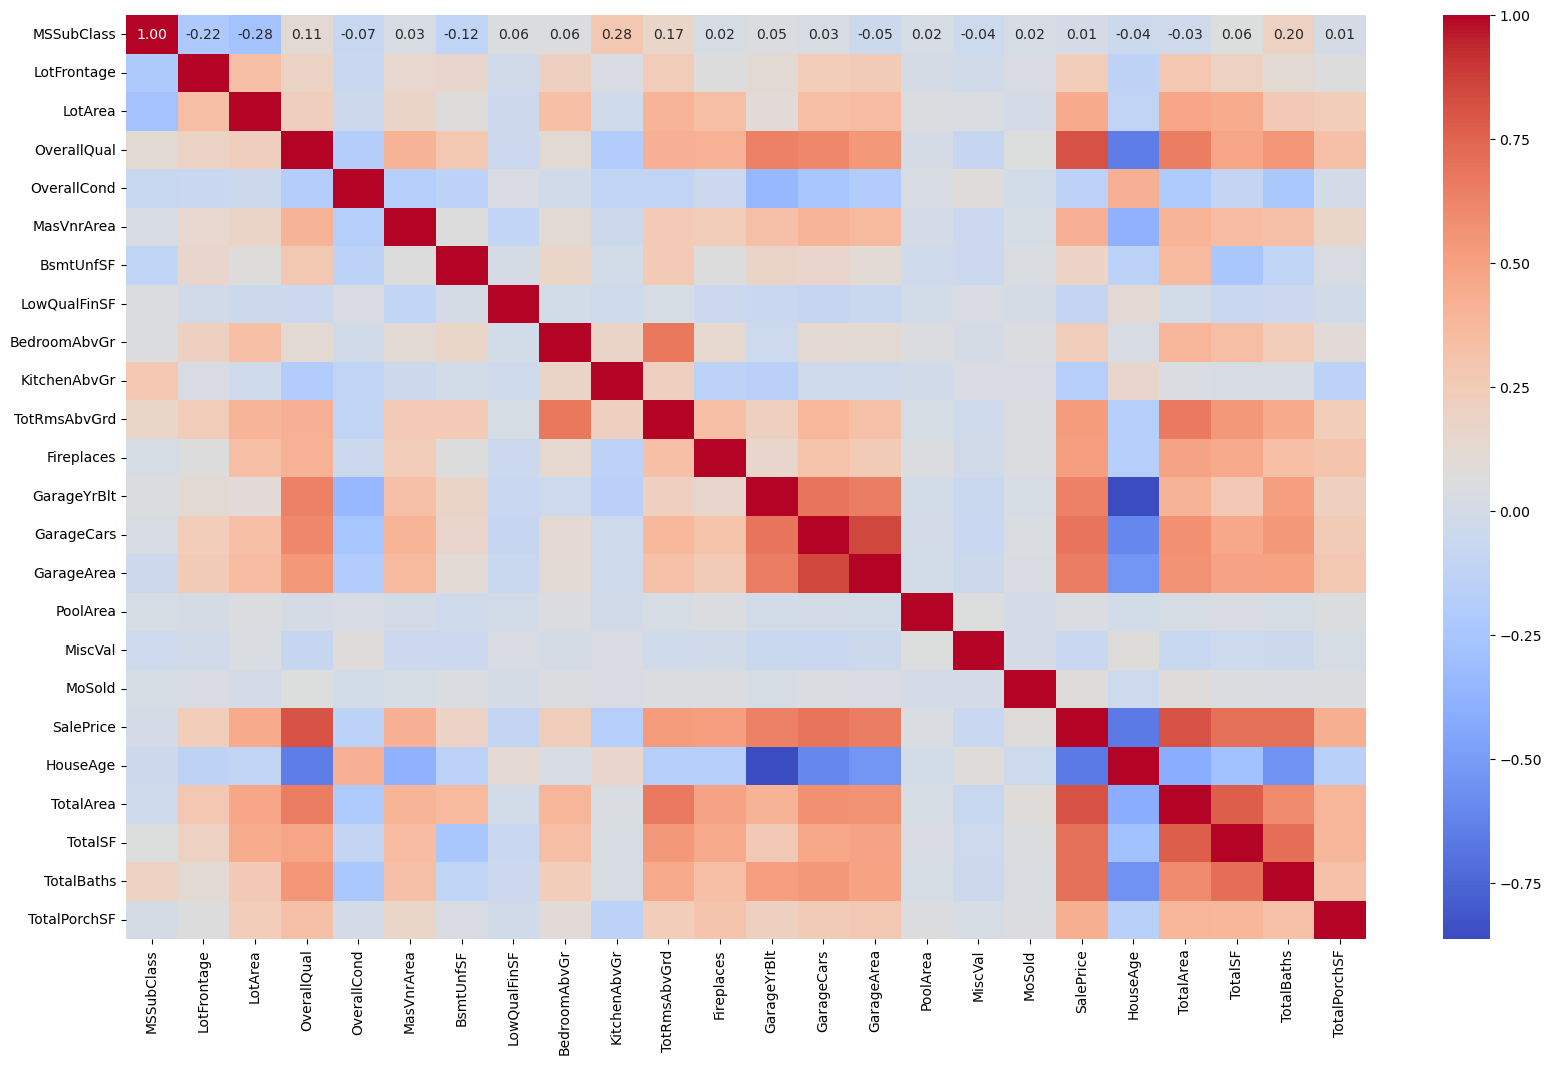

In [99]:
def matriz_correlación(df_train):
    matriz_corr_num = df_train.corr(numeric_only=True,method='spearman')
    plt.figure(figsize=(20,12))
    sns.heatmap(matriz_corr_num, annot=True, cmap='coolwarm', fmt=".2f")
    plt.show()

matriz_correlación(df_train)

In [100]:
df_train=df_train.drop(columns=['PoolArea','MiscVal','MoSold','MSSubClass']) #dejo solo las variables más interesantes
df_train=df_train.drop(columns=['GarageArea']) #variable basicamente repetida con GarageCars pero Garage Cars es más relevante

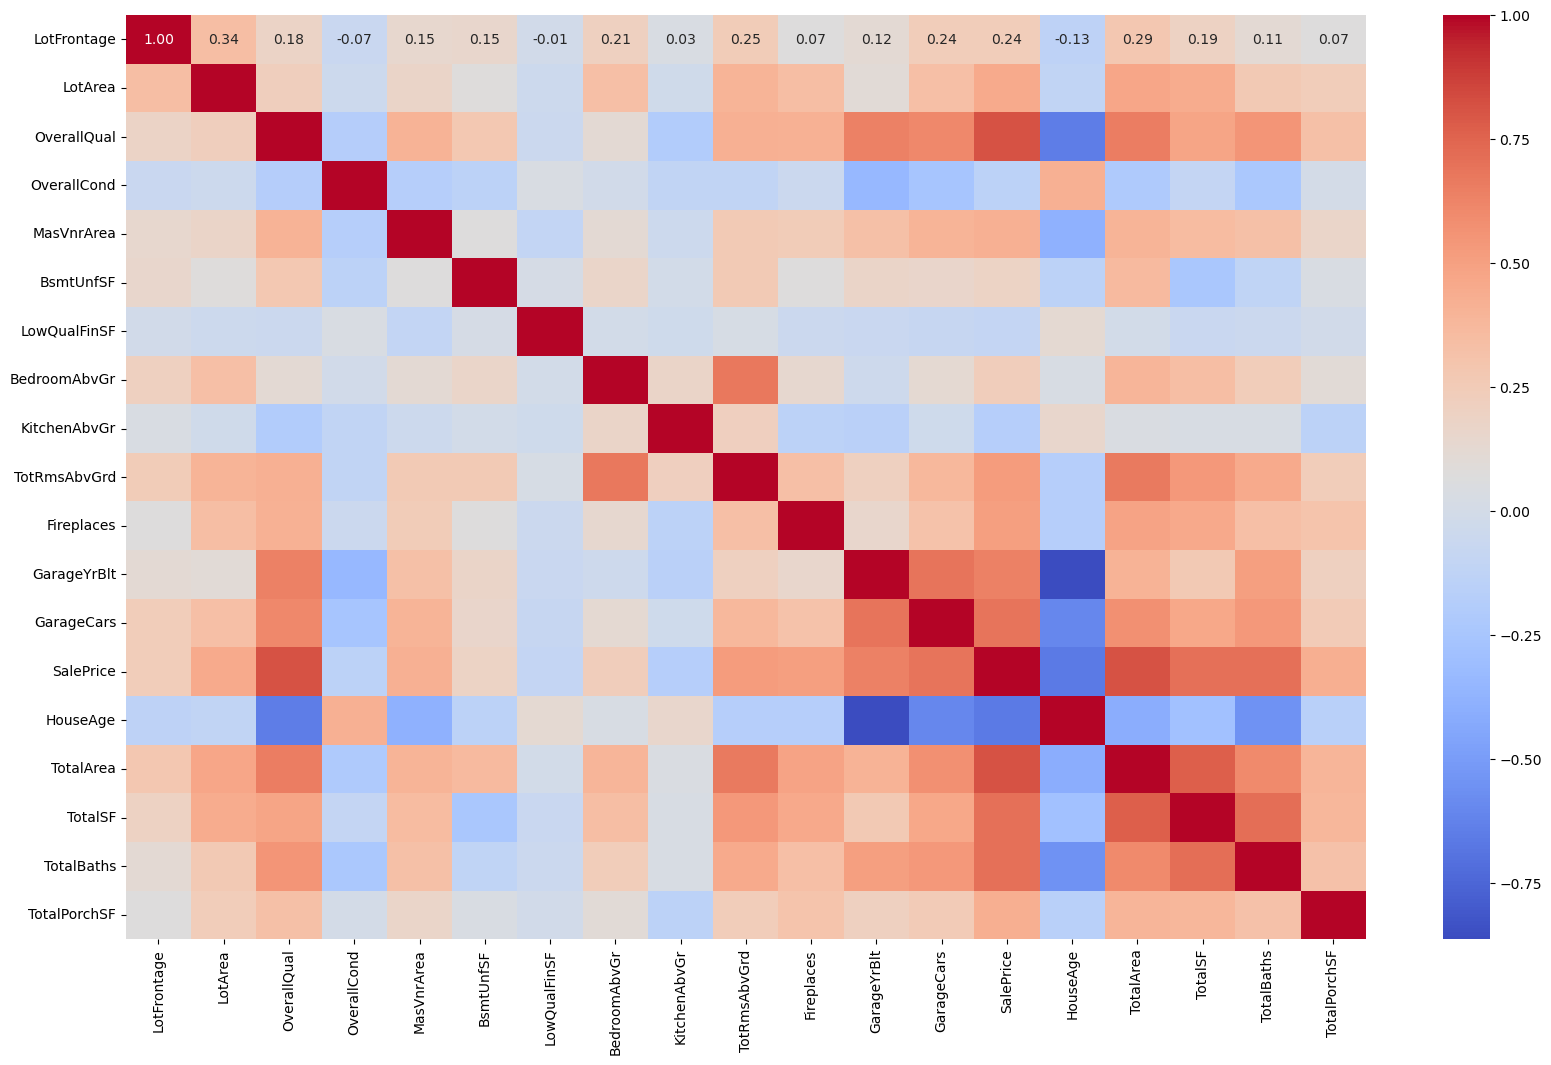

In [101]:
matriz_correlación(df_train)

Ahora nos encargamos de las variables no numéricas, como variables categóricas nominales(23) y ordinales(23). Para su tratamiento,

In [102]:
#Analizo un dataset hecho solo de las variables categóricas:
df_cat = df_train.dtypes[df_train.dtypes=='object']
df_cat

MSZoning         object
Street           object
Alley            object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
GarageCond       object
PavedDrive       object
PoolQC           object
Fence            object
MiscFeature      object
SaleType        

De la descripción de los datos del dataset que ofrece la competencia, hago una lista de las variables categóricas para aplicar OHE o ODE.  

In [103]:

def ausentes_cat(df):
    conteo_no = {}

    for col in df.columns:
        if df[col].dtype == object:
            # Convertimos a string y bajamos todo a minúsculas para asegurar coincidencias
            conteo = df[col].astype(str).str.lower().str.count(r'\bno\b').sum()
            conteo_no[col] = conteo

    # Ordenamos de mayor a menor según cantidad de "no"
    columnas_ordenadas = sorted(conteo_no.items(), key=lambda x: x[1], reverse=True)
    
    return columnas_ordenadas


In [104]:
ausentes_cat(df_train)


[('PoolQC', 1435),
 ('MiscFeature', 1388),
 ('Alley', 1350),
 ('Fence', 1162),
 ('BsmtExposure', 986),
 ('MasVnrType', 861),
 ('FireplaceQu', 684),
 ('GarageType', 76),
 ('GarageFinish', 76),
 ('GarageQual', 76),
 ('GarageCond', 76),
 ('BsmtQual', 37),
 ('BsmtCond', 37),
 ('BsmtFinType1', 37),
 ('MSZoning', 0),
 ('Street', 0),
 ('LotShape', 0),
 ('LandContour', 0),
 ('Utilities', 0),
 ('LotConfig', 0),
 ('LandSlope', 0),
 ('Neighborhood', 0),
 ('Condition1', 0),
 ('Condition2', 0),
 ('BldgType', 0),
 ('HouseStyle', 0),
 ('RoofStyle', 0),
 ('RoofMatl', 0),
 ('Exterior1st', 0),
 ('Exterior2nd', 0),
 ('ExterQual', 0),
 ('ExterCond', 0),
 ('Foundation', 0),
 ('BsmtFinType2', 0),
 ('Heating', 0),
 ('HeatingQC', 0),
 ('CentralAir', 0),
 ('Electrical', 0),
 ('KitchenQual', 0),
 ('Functional', 0),
 ('PavedDrive', 0),
 ('SaleType', 0),
 ('SaleCondition', 0)]

In [105]:
df_train = df_train.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence','BsmtExposure', 'GarageYrBlt', 'BsmtFinType2','MasVnrType','FireplaceQu'])
df_test = df_test.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'BsmtExposure','GarageYrBlt', 'BsmtFinType2','MasVnrType','FireplaceQu'])

In [106]:
ausentes_cat(df_train)

[('GarageType', 76),
 ('GarageFinish', 76),
 ('GarageQual', 76),
 ('GarageCond', 76),
 ('BsmtQual', 37),
 ('BsmtCond', 37),
 ('BsmtFinType1', 37),
 ('MSZoning', 0),
 ('Street', 0),
 ('LotShape', 0),
 ('LandContour', 0),
 ('Utilities', 0),
 ('LotConfig', 0),
 ('LandSlope', 0),
 ('Neighborhood', 0),
 ('Condition1', 0),
 ('Condition2', 0),
 ('BldgType', 0),
 ('HouseStyle', 0),
 ('RoofStyle', 0),
 ('RoofMatl', 0),
 ('Exterior1st', 0),
 ('Exterior2nd', 0),
 ('ExterQual', 0),
 ('ExterCond', 0),
 ('Foundation', 0),
 ('Heating', 0),
 ('HeatingQC', 0),
 ('CentralAir', 0),
 ('Electrical', 0),
 ('KitchenQual', 0),
 ('Functional', 0),
 ('PavedDrive', 0),
 ('SaleType', 0),
 ('SaleCondition', 0)]

In [107]:
ode_cols=['LotShape', 'LandContour','Utilities','LandSlope',  'BsmtQual',  'BsmtFinType1',  'CentralAir',  'Functional', 'GarageFinish', 'GarageQual', 'PavedDrive', 'ExterCond', 'KitchenQual', 'HeatingQC','ExterQual', 'BsmtCond']

In [108]:
ohe_cols=['Street', 'LotConfig','Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd','Foundation',  'Electrical',  'SaleType', 'MSZoning', 'SaleCondition', 'Heating', 'GarageType', 'RoofMatl']

NORMALIZACIÓN Y ESCALADORES

In [109]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('SalePrice')


In [110]:
num_pipeline = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='mean')),
    ('powertransformer', PowerTransformer()) #uso power transformer porque se asemeja a una Normal la Johnson SU
])

In [111]:
ode_pipeline = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='most_frequent')),
    ('oe', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [112]:
ohe_pipeline = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [113]:
df=ColumnTransformer(transformers=[
    ('num_flujo', num_pipeline, num_cols),
    ('ode_flujo', ode_pipeline, ode_cols),
    ('ohe_flujo', ohe_pipeline, ohe_cols),
    ],
    remainder='passthrough', 
    n_jobs=-1)
#las columnas no mencionadas déjalas igual

In [114]:
pipeline = Pipeline(steps=[
    ('preprocesado_total', df)
])
print(pipeline)

Pipeline(steps=[('preprocesado_total',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('num_flujo',
                                                  Pipeline(steps=[('imputar',
                                                                   SimpleImputer()),
                                                                  ('powertransformer',
                                                                   PowerTransformer())]),
                                                  Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea',
       'BsmtUnfSF', 'LowQualFinSF', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fi...
                                                  Pipeline(steps=[('imputar',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
 

Porque usar Pipeline en vez de las transformaciones clásicas?
- Puedo aplicar fit y transform en un solo objeto.
- Todo queda “empaquetado” para reutilizarlo fácilmente, por ejemplo, en validación cruzada.
- Con ColumnTransformer puedes aplicar distintos tratamientos a distintas columnas, todo en una sola estructura.


In [115]:
X = df_train.drop('SalePrice', axis=1)
y = df_train['SalePrice']

In [116]:
X_procesado=pipeline.fit_transform(X)
X_procesado=pd.DataFrame(X_procesado)
X_procesado


,0,1,2,3,4,5,6,7,8,9,...,174,175,176,177,178,179,180,181,182,183
0,0.302702,-0.174318,0.68457,-0.484206,1.235359,-0.88997,-0.127448,0.168837,-0.0,0.969991,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
1,0.696926,0.093749,-0.039298,2.012653,-0.816741,-0.436579,-0.127448,0.168837,-0.0,-0.232846,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
2,0.382896,0.439082,0.68457,-0.484206,1.19878,-0.050046,-0.127448,0.168837,-0.0,-0.232846,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
3,0.167364,0.08261,0.68457,-0.484206,-0.816741,0.181531,-0.127448,0.168837,-0.0,0.401098,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
4,0.799436,0.98147,1.386791,-0.484206,1.336872,0.075606,-0.127448,1.422021,-0.0,1.486726,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1434,0.221761,-0.307942,-0.039298,-0.484206,-0.816741,0.908269,-0.127448,0.168837,-0.0,0.401098,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
1435,0.824908,0.796849,-0.039298,0.440495,1.135907,0.280426,-0.127448,0.168837,-0.0,0.401098,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
1436,0.329514,-0.033121,0.68457,2.696438,-0.816741,0.789394,-0.127448,1.422021,-0.0,1.486726,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA
1437,0.382896,0.119645,-0.788748,0.440495,-0.816741,-2.066392,-0.127448,-1.073529,-0.0,-0.950394,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,TA


### Predicción-Entrenamiento <a name="global"> </a>


In [ ]:
# ========================
# 1. IMPORTS
# ========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')

# ========================
# 2. CARGA Y PREPROCESADO DE DATOS
# ========================
X = df_train.drop('SalePrice', axis=1)
y = df_train['SalePrice']
X_procesado=pipeline.fit_transform(X)
X_procesado=pd.DataFrame(X_procesado)

# ========================
# 3. SPLIT TRAIN/VALIDATION
# ========================
X_train, X_val, y_train, y_val = train_test_split(X_procesado, y, test_size=0.2, random_state=42)

# ========================
# 4. DEFINICIÓN DE MODELOS
# ========================
modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

# ========================
# 5. ENTRENAMIENTO, EVALUACIÓN Y GRÁFICOS
# ========================
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo

    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_val_pred = modelo.predict(X_val)

    # Cálculo de RMSE en validación
    error_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"{nombre}: RMSE en validación = {error_val:.4f}")

    # -------------------------------------
    # Gráfico 1: Actual vs Predicho (TRAIN)
    # -------------------------------------
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.6)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')  # Línea ideal
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"Actual vs Predicted - {nombre}")
    plt.show()

    # -------------------------------------
    # Gráfico 2: Residual Plot (TRAIN)
    # -------------------------------------
    residuals = y_train - y_train_pred

    plt.figure(figsize=(8,5))
    sns.scatterplot(x=y_train_pred, y=residuals, alpha=0.6)
    plt.axhline(0, color='r', linestyle='--')  # Línea horizontal en 0
    plt.xlabel("Predicted Prices")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.title(f"Residual Plot - {nombre}")
    plt.show()


### Predicción-Test <a name="global"> </a>


In [ ]:
# ========================
# 1. PROCESADO DE DATOS
# ========================

X_test = df_test.drop('Id', axis=1)  # Eliminamos la columna 'Id'
X_test_procesado = pipeline.transform(X_test) 

# ========================
# 2. HACER PREDICCIONES CON EL MODELO ELEGIDO
# ========================

mejor_modelo = modelos_entrenados["XGBoost"]  

# Predicciones sobre el conjunto de test
predicciones_test = mejor_modelo.predict(X_test_procesado)

# ========================
# 3. GENERAR EL DATAFRAME DE RESULTADOS
# ========================

# Crear un DataFrame con los IDs y los precios predichos
resultados = pd.DataFrame({
    'Id': df_test['Id'],  # La columna 'Id' del conjunto de test
    'SalePrice': predicciones_test  # Las predicciones generadas por el modelo
})

# ========================
# 4. GUARDAR EL ARCHIVO DE SALIDA
# ========================

# Guardamos el resultado en un archivo CSV
resultados.to_csv('./predicciones.csv', index=False)  
